In [11]:
import numpy as np
import matplotlib.pyplot as plt


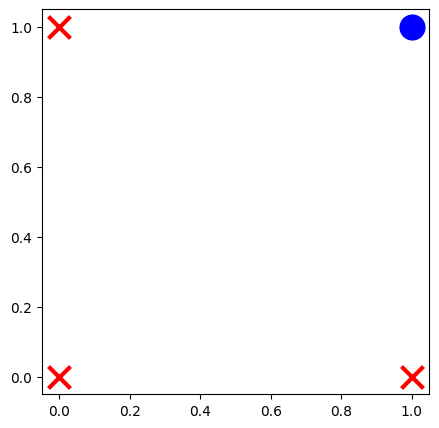

In [12]:
# 퍼셉트론 구현
def AND(x1 ,x2):
    x = np.array([x1,x2])
    w = np.array([0.5,0.5])
    b = -0.7
    tmp = np.sum(w*x) + b
    if tmp<=0:
        return 0
    else :
        return 1

points = [(0,0), (0,1), (1,0), (1,1)]

plt.figure(figsize=(5,5))
for x1, x2 in points:
    out = AND(x1, x2)
    color = 'blue' if out == 1 else 'red'
    marker = 'o' if out == 1 else 'x'
    plt.scatter(x1, x2, c=color, marker=marker, s=250, linewidths=3)

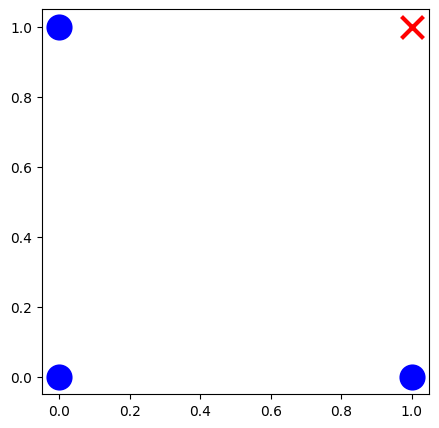

In [13]:
def NAND(x1 ,x2):
    x = np.array([x1,x2])
    w = np.array([-0.5,-0.5])
    b = 0.7
    tmp = np.sum(w*x) + b
    if tmp<=0:
        return 0
    else :
        return 1
points = [(0,0), (0,1), (1,0), (1,1)]
plt.figure(figsize=(5,5))
for x1, x2 in points:
    out = NAND(x1, x2)
    color = 'blue' if out == 1 else 'red'
    marker = 'o' if out == 1 else 'x'
    plt.scatter(x1, x2, c=color, marker=marker, s=250, linewidths=3)

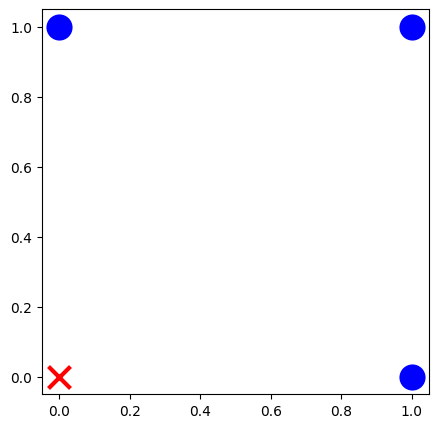

In [14]:
def OR(x1 ,x2):
    x = np.array([x1,x2])
    w = np.array([0.5,0.5])
    b = -0.2
    tmp = np.sum(w*x) + b
    if tmp<=0:
        return 0
    else :
        return 1

points = [(0,0), (0,1), (1,0), (1,1)]
plt.figure(figsize=(5,5))
for x1, x2 in points:
    out = OR(x1, x2)
    color = 'blue' if out == 1 else 'red'
    marker = 'o' if out == 1 else 'x'
    plt.scatter(x1, x2, c=color, marker=marker, s=250, linewidths=3)

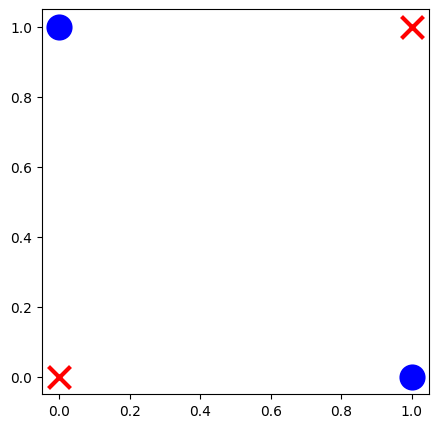

In [ ]:
# 기존 퍼셉트론들을 조합하여 XOR 구현하기
def XOR(x1,x2):
    s1 = NAND(x1,x2) # 입력층
    s2 = OR(x1,x2) # 은닉층
    y = AND(s1,s2) # 출력층
    return y

points = [(0,0), (0,1), (1,0), (1,1)]
plt.figure(figsize=(5,5))
for x1, x2 in points:
    out = XOR(x1, x2)
    color = 'blue' if out == 1 else 'red'
    marker = 'o' if out == 1 else 'x'
    plt.scatter(x1, x2, c=color, marker=marker, s=250, linewidths=3)

기울기 : 3.1500   (실제 값: 3.0)
절편: 6.8433   (실제 값: 7.0)
x=  0.0, y=6.8433
x=  5.0, y=22.5934
x= 12.0, y=44.6436


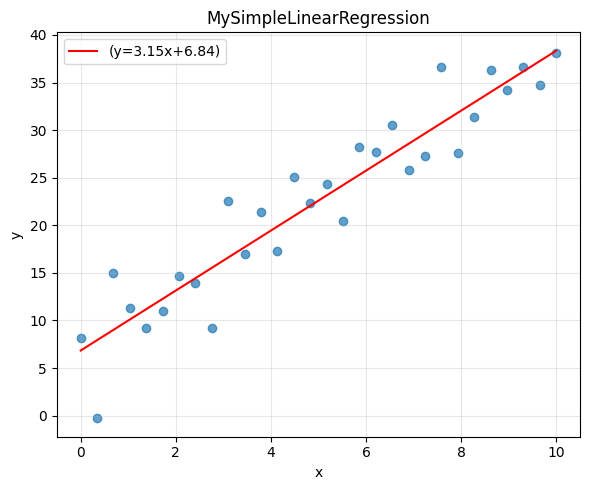

In [32]:
# 회귀 중 MSE를 사용한 회귀
class MySimpleLinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, Y):
        x = X[:,0]
        y = Y[:,0]

        xm = x.mean()
        ym = y.mean()
        ss = np.sum((x - xm)*(y - ym))
        xx = np.sum((x - xm)**2)
        self.coef_ = ss/xx
        self.intercept_ = ym - self.coef_ * xm
    
    def predict(self,X):
        x = X[:,0]
        return (self.intercept_ + self.coef_*x).reshape(-1,1)
    
#y = 3x + 7 + 랜덤값
x = np.linspace(0, 10, 30)
w,b = 3.0, 7.0
random = np.random.randn(30) * 3
y = w * x + b + random

X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

# 모델 학습
model = MySimpleLinearRegression()
model.fit(X, Y)

print(f"기울기 : {model.coef_:.4f}   (실제 값: {w})")
print(f"절편: {model.intercept_:.4f}   (실제 값: {b})")

Y_pred = model.predict(X)

# 새로운 x값에 대한 예측 테스트
X_new = np.array([[0], [5], [12]])
Y_new_pred = model.predict(X_new)
#예측값
for i, j in zip(X_new[:,0], Y_new_pred[:,0]):
    print(f"x={i:5.1f}, y={j :.4f}")

# --- 그래프 그리기 ---
plt.figure(figsize=(6,5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, Y_pred[:,0], 'r-', label=f'(y={model.coef_:.2f}x+{model.intercept_:.2f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('MySimpleLinearRegression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()